<a href="https://colab.research.google.com/github/SANTHIYAKARUPPANAN/House-Price-Prediction/blob/main/House_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Starting to build model by importing all the Python libraries

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

Reading the CSV file i.e the Housing dataset

In [4]:
pd.set_option('display.max_columns', None)
url="https://raw.githubusercontent.com/SANTHIYAKARUPPANAN/House_price_prediction/refs/heads/main/AmesHousing.csv"
df=pd.read_csv(url)

Exploring the dataset by plotting the charts

#House condition VS Sales Price




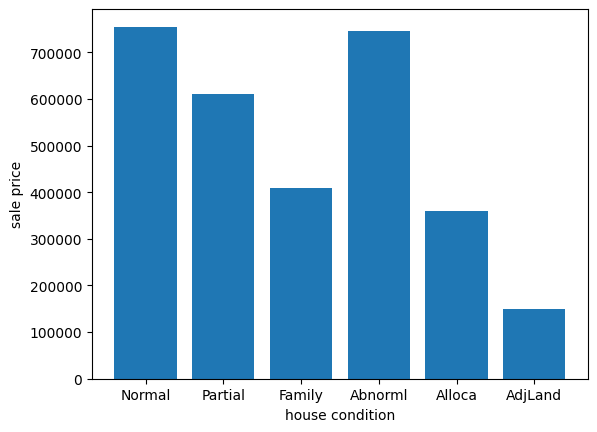

In [5]:
plt.bar(df["Sale Condition"],df["SalePrice"])
plt.xlabel("house condition")
plt.ylabel("sale price")
plt.show()

From the above chart one can conclude that Normal house condition House cost more and the AdjLand house condition cost the least

#garage area VS price

Text(0, 0.5, 'sale price')

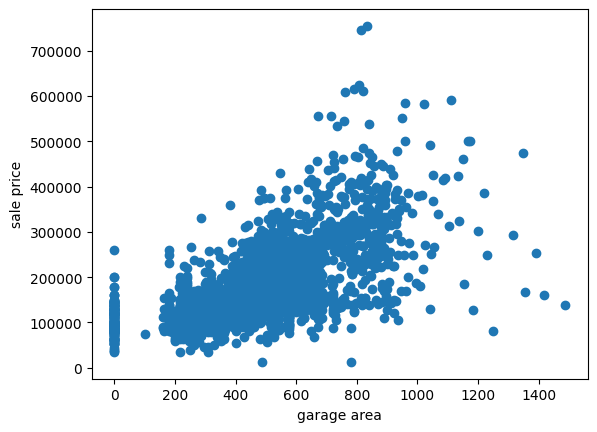

In [6]:
plt.scatter(df["Garage Area"],df["SalePrice"])
plt.xlabel("garage area")
plt.ylabel("sale price")

From the Above plot,we can observe that there is a correlation amongt the sale price and garage area .Also there exist outliers in garage area

#bedroom VS price



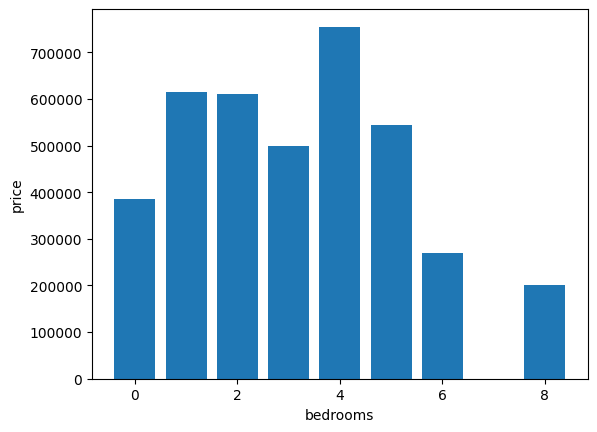

In [7]:
plt.bar(df["Bedroom AbvGr"],df["SalePrice"])
plt.xlabel("bedrooms")
plt.ylabel("price")
plt.show()

From the above chart price Vs bedrooms count ,we can't generalize anything .clearly number of bedroom feature does not influence the house price


#garage year built Vs price

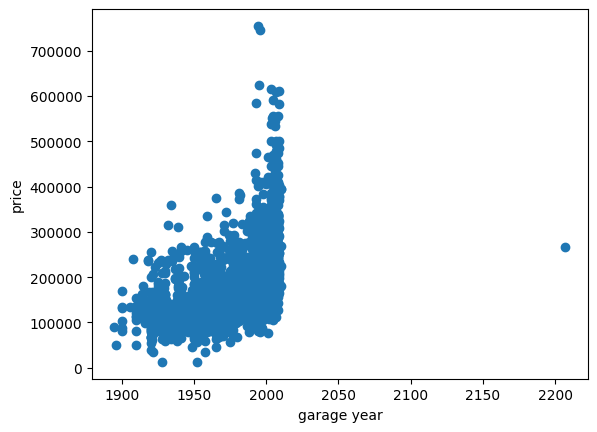

In [8]:
plt.scatter(df["Garage Yr Blt"],df["SalePrice"])
plt.xlabel("garage year")
plt.ylabel("price")
plt.show()

from the above plot i.e price Vs Garage Year.The houses in which the garages which are built recently cost more

#Garage Finish VS sales price

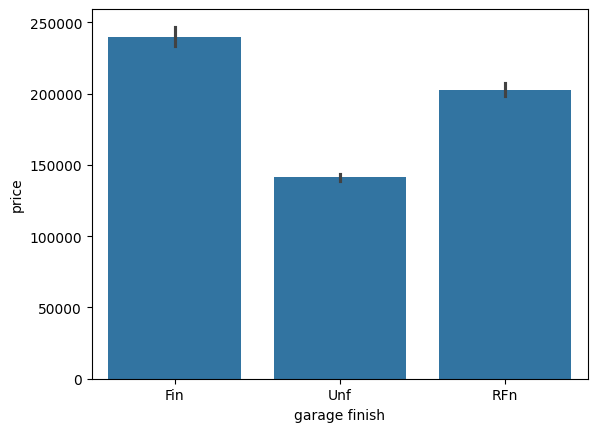

In [9]:
sns.barplot(x=df["Garage Finish"],y=df["SalePrice"])
plt.xlabel("garage finish")
plt.ylabel("price")
plt.show()

from the above plot ,we can find that finshed house has the high sales price than roughly finished than unfinished

#total rooms VS price

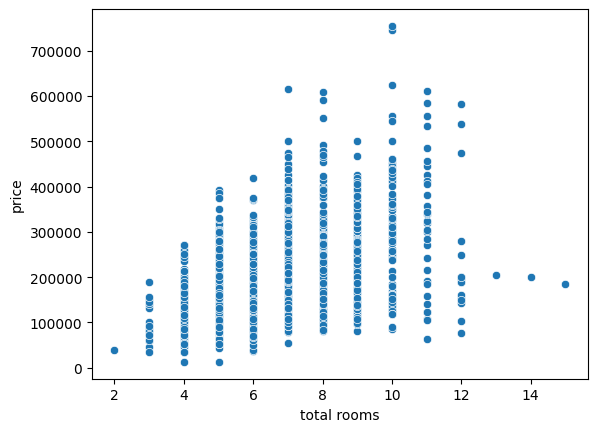

In [10]:
sns.scatterplot(x=df["TotRms AbvGrd"],y=df["SalePrice"])
plt.xlabel("total rooms")
plt.ylabel("price")
plt.show()

from the above Total Rooms Vs SalePrice plot ,Saleprice increases with increasing Total rooms and also we can find the outliers

#total basement surface VS sales price

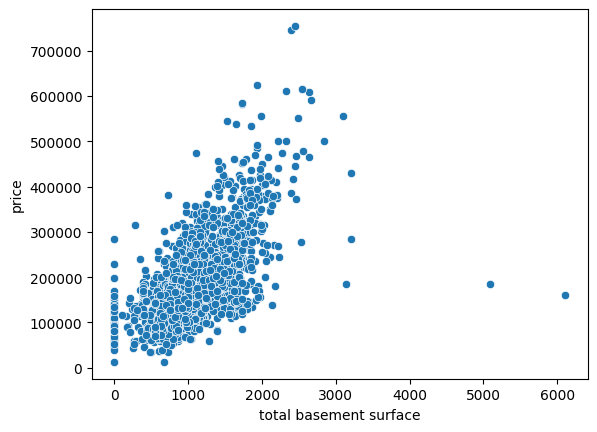

In [11]:
sns.scatterplot(x=df["Total Bsmt SF"],y=df["SalePrice"])
plt.xlabel("total basement surface")
plt.ylabel("price")
plt.show()

from the above plot Total Basement Surface Vs Sale Price,we can observe that total basement surface has a n influence in the house price and it also has outliers

To find the Correlation between the features and the target features SalePrice

In [12]:
df.corr(numeric_only=True)["SalePrice"].sort_values(ascending=False)

,SalePrice
SalePrice,1.000000
Overall Qual,0.799262
Gr Liv Area,0.706780
Garage Cars,0.647877
Garage Area,0.640401
Total Bsmt SF,0.632280
1st Flr SF,0.621676
Year Built,0.558426
Full Bath,0.545604
Year Remod/Add,0.532974


from the above correlation tabular column the features:"Overall Qual",
"Gr Liv Area","Garage Cars","Garage Area","Total Bsmt SF","Year Built".. has the most correlation with the target feature.


As of now,we found the features which are all related more to the target feature.Now we are picking only those features and clean it.
This ensures that we are working on useful features and not wasting time by cleaning the whole dataset of 63 features.

We are making the copy of the features that we want to avoid the copywarning.(features except target feature)

In [13]:
features=df[["Overall Qual",
 "Gr Liv Area",
 "Total Bsmt SF",
 "Garage Finish",
 "Garage Yr Blt",
 "TotRms AbvGrd",
 "Year Built"]].copy()

Now we are making the copy of target feature.

In [14]:
target=df["SalePrice"].copy()

Now comes the Data Cleaning Process.Let's Dive Deep into it.

Let's find how many of the selected features has null values and how much.

In [15]:
features.isnull().sum()

,0
Overall Qual,0
Gr Liv Area,0
Total Bsmt SF,1
Garage Finish,159
Garage Yr Blt,159
TotRms AbvGrd,0
Year Built,0


As you can see above that there are about
1 null value in "Total Bsmt SF",
159 null value in "Garage Finish",
159 null value in "Garage Yr Blt"

as you observe null values in garage finish and garage yr built is same ,where we can confidently tell that the house does not have garage.

Let's fix the "Total Bsmt SF" feature first.
since this is a numerical column ,it's better to fill null value with the median of that particular feature.

In [16]:
m=features["Total Bsmt SF"].median()
features.loc[features["Total Bsmt SF"].isnull(),"Total Bsmt SF"]=m

Let's verify whether the null value in the "Total Bsmt SF" feature is filled.

In [17]:
features["Total Bsmt SF"].isnull().sum()

np.int64(0)

As you can see,the null value in the "Total Bsmt SF" feature is filled.

Let's move on to next feature"



  "Garage Yr Bl" feature has 159 null values,which says that the houses does not have garages .Therefore we will fill the null values with 0.
  Ofcourse filling 0 in the year column will make no sense ,but later on while doing feature engineering we will create a column which tells whether there exist garage or not.

In [18]:
features.loc[features["Garage Yr Blt"].isnull(),"Garage Yr Blt"]=0

Now creating the new feature to mention whether there is garage or not.

In [19]:
features["Garage"] = (features["Garage Yr Blt"] != 0).astype(int)

Let's fill the null values in the "Garage Finish" by "NoGarage".

In [20]:
features.loc[features["Garage Finish"].isnull(),["Garage Finish"]]="NoGarage"

Now we have completed filling the null values in the features.

Now,the next step is to handle the outliers in each numerical  columns.Since,we are going use the regression models like lineaar regression .because it will be affected more by the outliers which inturn reduces the accuracy of the model.this step i.e outliers handling is not needed incase if you use random forest and XG boost algorithms.

Since we have two Area features.let's combine the area featurees together and then detect the outliers.

In [21]:
features["Total SF Area"]=features["Gr Liv Area"]+features["Total Bsmt SF"]
features.head()

,Overall Qual,Gr Liv Area,Total Bsmt SF,Garage Finish,Garage Yr Blt,TotRms AbvGrd,Year Built,Garage,Total SF Area
0,6,1656,1080.0,Fin,1960.0,7,1960,1,2736.0
1,5,896,882.0,Unf,1961.0,5,1961,1,1778.0
2,6,1329,1329.0,Unf,1958.0,6,1958,1,2658.0
3,7,2110,2110.0,Fin,1968.0,8,1968,1,4220.0
4,5,1629,928.0,Fin,1997.0,6,1997,1,2557.0


Now,let's check whether the feature is skewed i.e does it have outliers?

In [22]:
features["Total SF Area"].skew()

np.float64(1.517216424019917)

from the above result.we can see that the feature is skewed i.e value is >1(positively skewed).
let's fix this by log Transformation.

In [23]:
features["Total SF Area"]=np.log1p(features["Total SF Area"])


After Transformation.Let's check the skewness.

In [24]:
features["Total SF Area"].skew()

np.float64(-0.35189187384644166)

As you see the skewness after log transformation.It becomes in the range of (-0.5,0.5).

we have applied log transformation for target feature too.Because applying log only to the predictor feature wont work.

In [25]:
target=np.log1p(target)
target.skew()

np.float64(-0.014772659537224382)

Till now,we have completed filling the null values and handled outliers.

Let's start feature engineering.
creating dummies for all the categorical features.
creating dummies for "Garage Finish"

In [26]:
features=pd.get_dummies(features,columns=["Garage Finish"],dtype=int,drop_first=True)
features.head()

,Overall Qual,Gr Liv Area,Total Bsmt SF,Garage Yr Blt,TotRms AbvGrd,Year Built,Garage,Total SF Area,Garage Finish_NoGarage,Garage Finish_RFn,Garage Finish_Unf
0,6,1656,1080.0,1960.0,7,1960,1,7.914618,0,0,0
1,5,896,882.0,1961.0,5,1961,1,7.483807,0,0,1
2,6,1329,1329.0,1958.0,6,1958,1,7.885705,0,0,1
3,7,2110,2110.0,1968.0,8,1968,1,8.347827,0,0,0
4,5,1629,928.0,1997.0,6,1997,1,7.846981,0,0,0


Till now every data processing is completed.
Let's start building the model.

Copying and creating a New datafram where we store only the needed column.

In [27]:
req=features[["Overall Qual","Garage Yr Blt","TotRms AbvGrd","Year Built","Garage","Total SF Area","Garage Finish_NoGarage","Garage Finish_RFn","Garage Finish_Unf"]].copy()

importing the model from the scikit-learn library.Let's try one by one and checks it accuracy

But before training the model,we should split the training dataset into two parts i.e for training and test data.Before predicting the model with new datset,with the help of test data we can verify the model's performance .

In [28]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(req,target,test_size=0.2,random_state=42)

1.Linear Regression

In [29]:
from sklearn.linear_model import LinearRegression
modal=LinearRegression()
modal.fit(x_train,y_train)

LinearRegression()

Now,we trained a linearRegression model.we can evaluate this by using the test dataset.

In [30]:
pred=modal.predict(x_test)


To find the accuracy of the trained model,we use several metrics like mse,mae,r2_score etc,,

In [31]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
print("mae:",mean_absolute_error(y_test,pred))
print("mse:",mean_squared_error(pred,y_test))
print("r2_score:",r2_score(pred,y_test))

mae: 0.11623895763900546
mse: 0.02557360411169921
r2_score: 0.836282829002819


From the above model evaluation,the r2_score metric has the more error among the all the three metrics.

2.Decision Tree

In [32]:
from  sklearn.tree import DecisionTreeRegressor
model=DecisionTreeRegressor(max_depth=8,
    min_samples_split=9,
    random_state=20)
model.fit(x_train,y_train)


DecisionTreeRegressor(max_depth=8, min_samples_split=9, random_state=20)

Let's predict the x_test dataset and evaluate with y_test

In [33]:
predict=model.predict(x_test)


In [34]:
print("mae:",mean_absolute_error(y_test,predict))
print("mse:",mean_squared_error(predict,y_test))
print("r2_score:",r2_score(predict,y_test))

mae: 0.1176612184835175
mse: 0.030314222382233486
r2_score: 0.8263974458505123


3.Rnadom Forest

In [35]:
from sklearn.ensemble import RandomForestRegressor
final_model=RandomForestRegressor(n_estimators=200,
    max_depth=10,
    min_samples_split=8,
    random_state=42)
final_model.fit(x_train,y_train)
prediction=final_model.predict(x_test)
print("mae:",mean_absolute_error(y_test,prediction))
print("mse:",mean_squared_error(prediction,y_test))
print("r2_score:",r2_score(prediction,y_test))

mae: 0.10672296723413746
mse: 0.023678512826692918
r2_score: 0.8588970942479079


Among the above the regression models ,Random Forest has the highest accuracy score.Therefore it is selected for final prediction

Saving the final model

In [36]:
import joblib
joblib.dump(final_model, "house_price_model.pkl")

['house_price_model.pkl']

In [37]:
import joblib
import numpy as np
import pandas as pd
def house_price_prediction(qual, garage_yr, tot_rooms, year_built, Garage, area, nogarage, rough_finish, unfinish):

    model = joblib.load("house_price_model.pkl")

    input_data = pd.DataFrame({
        "Overall Qual": [qual],
        "Garage Yr Blt": [garage_yr],
        "TotRms AbvGrd": [tot_rooms],
        "Year Built": [year_built],
        "Garage": [Garage],
        "Total SF Area": [area],
        "Garage Finish_NoGarage": [nogarage],
        "Garage Finish_RFn": [rough_finish],
        "Garage Finish_Unf": [unfinish]
    })
    features[["Overall Qual","Garage Yr Blt","TotRms AbvGrd","Year Built","Garage","Total SF Area","Garage Finish_NoGarage","Garage Finish_RFn","Garage Finish_Unf"]].copy()
    prediction = model.predict(input_data)
    # convert from log to original price
    prediction = np.expm1(prediction)
    return prediction[0]
# ---------- USER INPUT ----------
qual = int(input("Enter the overall quality of the house: "))
tot_rooms = int(input("Enter the total number of rooms: "))
year_built = int(input("Enter the year in which the house was built: "))
Garage = int(input("Is there a garage? (1 = Yes, 0 = No): "))
garage_yr = 0
nogarage = 0
rough_finish = 0
unfinish = 0
if Garage == 1:
    garage_yr = int(input("Enter the year in which the garage was built: "))
    print("Enter the stage of the garage:")
    print("1 = Rough finished")
    print("2 = Unfinished")
    Garage_cond = int(input())
    if Garage_cond == 1:
        rough_finish = 1
    else:
        unfinish = 1
else:
    nogarage = 1
area = int(input("Enter the total area of the house: "))
area = np.log1p(area)
# ---------- PREDICTION ----------
rate = house_price_prediction(
    qual, garage_yr, tot_rooms, year_built,
    Garage, area, nogarage, rough_finish, unfinish
)
print("Predicted House Price: ₹",round(rate,2))

Enter the overall quality of the house: 9
Enter the total number of rooms: 3
Enter the year in which the house was built: 2000
Is there a garage? (1 = Yes, 0 = No): 1
Enter the year in which the garage was built: 2020
Enter the stage of the garage:
1 = Rough finished
2 = Unfinished
1
Enter the total area of the house: 256734
Predicted House Price: ₹ 246495.47
